In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# read in all words
words = open('D:\\Vault-4\\Projects\\makemore\\names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(f'{vocab_size} unique characters: {itos}')

27 unique characters: {1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [52]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

print(Xtr.shape, Ytr.shape)
print(Xdev.shape, Ydev.shape)
print(Xte.shape, Yte.shape)

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])
torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [ ]:
# MLP model
n_embd = 10 # the dimensionality of the character embeddings
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g) # character embedding table
W1 = torch.randn((block_size*n_embd, n_hidden), generator=g)*(5/3)/((block_size*n_embd)**0.5) #0.1 # weights for the hidden layer
# b1 = torch.randn(n_hidden, generator=g)*0.01 # bias for the hidden layer
W2 = torch.randn((n_hidden, vocab_size), generator=g)*0.01 # weights for the output layer
b2 = torch.randn(vocab_size, generator=g)*0 # bias for the output layer

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
# 指数滑动平均（EMA）维护的全局统计量，用于推理时替代 mini-batch 统计量
# 初始值：mean=0, std=1（标准正态假设）
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

# parameters = [C, W1, b1, W2, b2]
parameters = [C, W1, W2, b2]

for p in parameters:
    p.requires_grad = True
print(sum(p.nelement() for p in parameters), 'parameters')

11697 parameters


## Batch Normalization（批归一化）

训练循环中这一行是手动实现的 BN：
```python
hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
```

### 公式拆解

对 `hpreact` 形状 $(B, n\_hidden)$，沿 batch 维度（`dim=0`）计算：

$$\mu_j = \frac{1}{B}\sum_{i=1}^{B} x_{ij}, \quad \sigma_j = \sqrt{\frac{1}{B}\sum_{i=1}^{B}(x_{ij}-\mu_j)^2}$$

$$\hat{x}_{ij} = \gamma_j \cdot \frac{x_{ij} - \mu_j}{\sigma_j} + \beta_j$$

其中 $\gamma$ = `bngain`（初始 1），$\beta$ = `bnbias`（初始 0）。

### 目的

1. **防止 tanh 饱和**：将 `hpreact` 拉回均值 0、标准差 1 的范围，让大部分值落在 tanh 的线性区（约 $[-1,1]$），避免梯度消失
2. **解耦层间依赖**：前面层参数变化不会让后面层输入分布漂移（Internal Covariate Shift）
3. **降低对初始化的敏感度**：即使初始化不佳，BN 也会自动把分布拉正
4. **$\gamma, \beta$ 保留表达能力**：标准化后再通过可学习参数缩放/偏移，网络可以自己决定最终分布

### Mini-batch 噪声 → 免费的正则化

因为 $\mu, \sigma$ 是在**随机抽取的 mini-batch**（这里 batch_size=32）上计算的，不是全局精确统计量，所以同一个样本在不同 batch 中会得到略不同的标准化结果。这种"抖动"等价于给网络注入了噪声，迫使网络学习对扰动鲁棒的特征，天然起到 **正则化** 效果（类似 Dropout）。batch 越小噪声越大。

> 推理时不能用 mini-batch 统计量（否则预测会抖动），需要用训练期间的全局 running mean/std。

In [ ]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors, (batch_size, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors, (batch_size, block_size*n_embd)
    # hpreact = embcat @ W1 + b1 # hidden layer pre-activation, (batch_size, n_hidden)
    hpreact = embcat @ W1 # + b1 因为后面会直接减去均值，偏置项直接没了？ # hidden layer pre-activation, (batch_size, n_hidden)
    
    ### 尽量不要使用batchnorm,会导致很多bug。最好使用groupnorm或者layernorm
    # minibatch normalization
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)

    hpreact = bngain * (hpreact - bnmeani) / (bnstdi + 1e-5) + bnbias
    h = torch.tanh(hpreact) # hidden layer, (batch_size, n_hidden)
    logits = h @ W2 + b2 # output layer pre-activation, (batch_size, vocab_size)
    loss = F.cross_entropy(logits, Yb) # loss function

    # 用 EMA 在训练过程中在线维护全局 mean/std，供推理时使用
    # momentum=0.001: running ≈ 反映最近 ~1000 个 batch 的平均，更平滑
    # 不参与梯度计算（torch.no_grad），不是可学习参数
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.item())    

    # break

      0/200000: 3.2856
  10000/200000: 2.1602
  20000/200000: 2.1000
  30000/200000: 2.2774
  40000/200000: 2.0228
  50000/200000: 1.6972
  60000/200000: 2.3024
  70000/200000: 2.2081
  80000/200000: 2.3831
  90000/200000: 2.0636
 100000/200000: 2.1042
 110000/200000: 2.2475
 120000/200000: 2.2926
 130000/200000: 1.9509
 140000/200000: 1.8132
 150000/200000: 2.1272
 160000/200000: 2.0113
 170000/200000: 1.9760
 180000/200000: 2.1236
 190000/200000: 2.0509


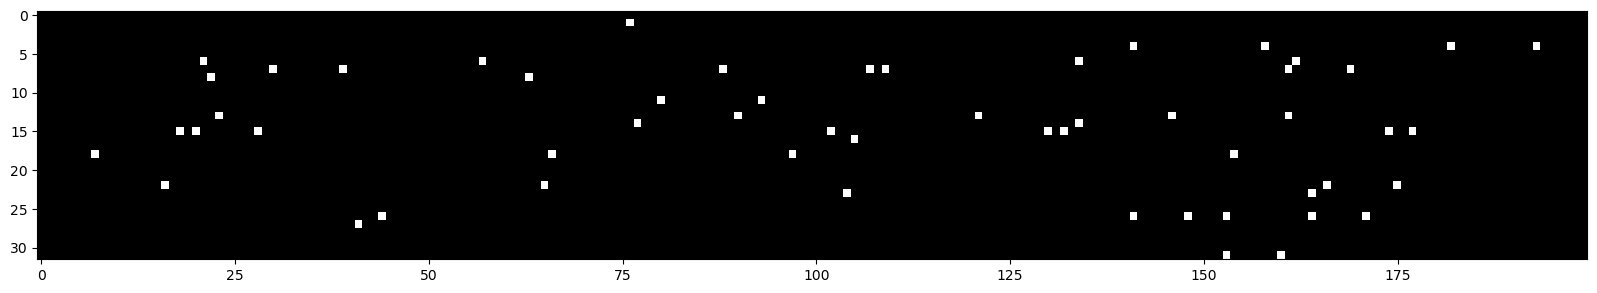

In [56]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs()>0.99, cmap='gray', interpolation='nearest')

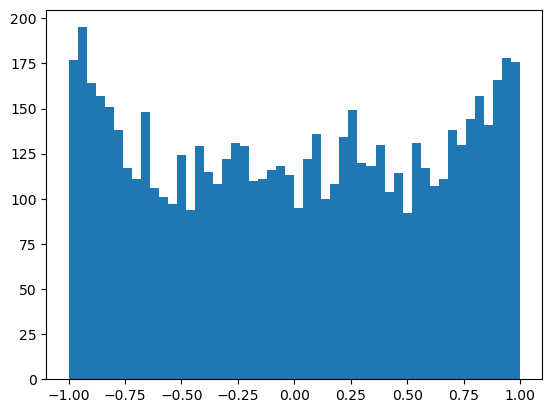

In [57]:
plt.hist(h.view(-1).tolist(), 50);

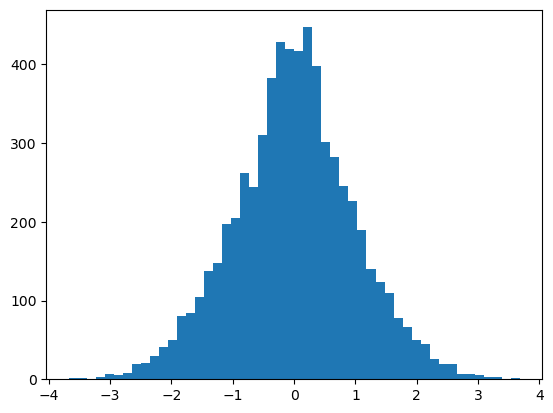

In [58]:
plt.hist(hpreact.view(-1).tolist(), 50);

In [59]:
# 4-dimensional example
# logits = torch.tensor([-3.0, 5.0, 0.0, 0.0])
logits=torch.randn(4)*0.1
probs=torch.softmax(logits, dim=0)
loss=max(-probs.log())
logits, probs, loss

(tensor([ 0.0634, -0.0883,  0.1190,  0.0786]),
 tensor([0.2543, 0.2185, 0.2689, 0.2582]),
 tensor(1.5208))

In [60]:
-torch.tensor(1/27).log()

tensor(3.2958)

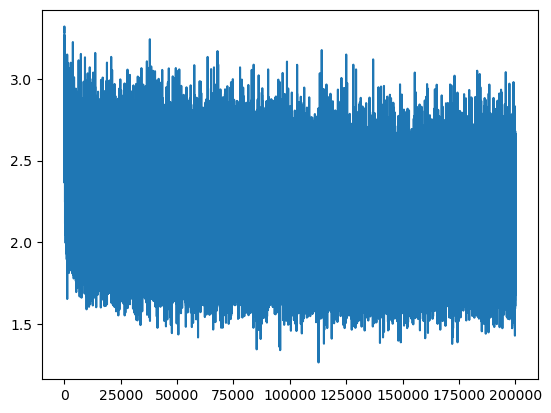

In [61]:
plt.plot(lossi)

In [62]:
# # 训练结束后校准 BN：用整个训练集计算全局 mean/std
# # 训练时用的是 mini-batch 的统计量（有噪声），推理时需要稳定的全局统计量
# with torch.no_grad():
#     # 把整个训练集跑一遍前向传播（不需要梯度）
#     emb=C[Xtr] 
#     embcat=emb.view(emb.shape[0],-1) 
#     hpreact=embcat @ W1 + b1 
#     # 在全部训练样本上计算每个神经元的均值和标准差 → 形状 (1, n_hidden)
#     bnmean=hpreact.mean(0,keepdim=True) 
#     bnstd=hpreact.std(0,keepdim=True)
# # 有了bnmean_running和bnstd_running，就可以在推理时使用它们来进行标准化，而不是使用当前输入的统计量。这确保了模型在推理时的稳定性和一致性。


In [63]:
bnmean

tensor([[-2.8380e+00, -1.8016e-01, -9.9055e-01,  1.5510e+00,  1.5799e+00,
          1.2921e+00,  2.8164e+00, -2.6973e+00, -6.0096e-01, -1.1712e-01,
         -2.5481e+00, -2.4141e+00, -7.6731e-01,  1.4484e+00, -2.0777e-01,
         -8.2725e-01,  1.1551e+00, -2.5867e+00,  5.1531e-01,  7.8874e-01,
         -8.7356e-01,  1.7202e-01,  1.0906e+00,  1.3523e+00,  9.4517e-01,
          2.0740e+00,  1.7676e+00, -7.7658e-01,  8.0066e-01,  2.4132e+00,
         -1.5562e-01, -1.8539e+00, -1.3886e+00, -1.7807e+00, -8.6411e-02,
         -2.4439e+00, -2.9088e+00,  1.0836e+00, -1.7013e+00,  8.1811e-01,
          3.3975e-01, -2.8976e-01,  2.4559e-01,  1.1649e+00,  1.6574e+00,
          1.7753e+00,  4.5378e+00, -1.1334e+00,  1.8924e+00,  2.5165e+00,
          8.9078e-01, -5.5501e-01,  2.3181e+00,  1.8118e+00,  1.0333e+00,
         -2.2289e+00, -3.9450e-01,  9.9635e-01,  2.8239e+00, -4.2559e+00,
         -1.8475e-03,  8.5119e-01,  7.2434e-02,  8.1511e-01,  3.3026e+00,
          9.1603e-01, -3.8289e-01,  2.

In [64]:
bnmean_running

tensor([[-2.5135,  0.2528, -0.9403,  2.4917,  1.1341,  0.4972,  1.5850, -0.4010,
          1.0054,  1.3063, -1.4261, -1.6055, -1.4548, -0.1558, -1.0781, -0.4144,
         -0.0214, -1.7498,  0.0560,  0.9488, -0.2632,  0.2604, -0.4775,  0.7900,
          0.6604,  1.6746,  1.1136, -0.6832,  1.0425,  2.0280,  0.3276, -1.0803,
          0.2818, -0.1916, -0.2717, -0.6544, -0.9888,  1.3622,  1.3289,  0.6116,
          0.0112, -1.1742, -0.6080,  0.4084,  0.8200, -0.3498,  1.4445, -1.3204,
          2.3291,  1.1076,  1.1443,  0.0506,  1.8141,  0.7909,  1.0614, -2.0825,
         -0.2212, -0.1298,  2.0742, -1.4166, -1.7198,  0.2990,  0.5998,  0.9910,
          0.7332,  0.4416, -0.0867,  1.6408, -0.4217, -0.7026, -0.1851,  0.6422,
          0.4436, -2.2991, -1.9512, -0.2105,  1.4369,  0.2965, -0.7962,  0.8927,
          0.0921,  0.9500,  1.0011,  1.0313, -0.1458,  0.2431, -0.5314,  0.2410,
          0.3703,  0.0487, -0.8355,  1.8400,  0.2846, -2.1311, -1.6866,  0.9873,
         -1.0684, -0.4262, -

In [65]:
@torch.no_grad() # this decorator disables gradient tracking
def spilt_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'dev': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # (N, block_size*n_embd)
    # hpreact = embcat @ W1 + b1 # (N, n_hidden)
    hpreact = embcat @ W1 # + b1 因为后面会直接减去均值，偏置项直接没了？ # (N, n_hidden)  

    # 推理时用校准后的全局 bnmean/bnstd 替代 mini-batch 统计量，保证输出确定性
    # hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / (hpreact.std(0, keepdim=True)) + bnbias
    hpreact = bngain * (hpreact - bnmean) / (bnstd + 1e-5) + bnbias  # +1e-5 防止除零
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(f'{split} loss: {loss.item():.4f}')

spilt_loss('train')
spilt_loss('dev')

train loss: 2.4232
dev loss: 2.4459


In [66]:
embcat.shape, W1.shape, hpreact.shape

(torch.Size([32, 30]), torch.Size([30, 200]), torch.Size([32, 200]))

In [67]:
# sample from the model
g = torch.Generator().manual_seed(2147483647+10)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        # forward pass the current context
        emb = C[torch.tensor([context])] # (1, block_size, n_embd)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1) # (1, n_hidden)
        logits = h @ W2 + b2 # (1, vocab_size)
        probs = F.softmax(logits, dim=1) # (1, vocab_size)

        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()

        # shift the context and append the new character
        context = context[1:] + [ix]
        out.append(ix)

        # if we sampled the special end token, break
        if ix == 0:
            break

    print(''.join(itos[i] for i in out)) # decode and print the generated word


brith.
myanziyer.
ndhnyah.
brith.
jendram.
cadelynn.
lillimp.
jenne.
singslina.
skatzivhonta.
nyshubrrgshirah.
krizh.
brennix.
brudrius.
kyedn.
kymbubzeh.
brie.
kharlyleahna.
kadylisuniz.
khlbduleigh.


In [ ]:
#losslog 
# original: 
train 2.1245384216308594 
val 2.168196439743042 

# fix softmax confidently wrong: 
train 2.07 
val 2.13

# fix tanh layer too saturated at init: 
train 2.0355966091156006 
val 2.1026785373687744

# add batchnorm:
train 2.0786
dev 2.1128

# delete the b1 momentum=0.001
train loss: 2.4232
dev loss: 2.4459



SyntaxError: invalid syntax (3908104544.py, line 3)

tensor(0.0035) tensor(0.9983)
tensor(-0.0020) tensor(1.0055)


(array([6.08145461e-05, 2.02715154e-05, 6.08145461e-05, 1.82443638e-04,
        2.02715154e-04, 5.06787885e-04, 6.89231523e-04, 9.52761223e-04,
        1.56090668e-03, 2.33122427e-03, 4.33810429e-03, 6.46661341e-03,
        1.10074329e-02, 1.82443638e-02, 2.98193991e-02, 4.40297314e-02,
        6.87204371e-02, 1.02249524e-01, 1.49401068e-01, 2.09972356e-01,
        2.74983106e-01, 3.46176668e-01, 4.03443699e-01, 4.29958841e-01,
        4.24262545e-01, 3.85665580e-01, 3.21729221e-01, 2.48184163e-01,
        1.88362921e-01, 1.31440506e-01, 9.02285150e-02, 5.89292952e-02,
        3.91645677e-02, 2.35757724e-02, 1.42306038e-02, 9.14245344e-03,
        5.67602431e-03, 3.18262792e-03, 1.92579396e-03, 1.25683395e-03,
        7.50046069e-04, 4.66244854e-04, 3.85158792e-04, 1.62172123e-04,
        1.21629092e-04, 2.02715154e-05, 2.02715154e-05, 2.02715154e-05,
        0.00000000e+00, 2.02715154e-05]),
 array([-5.87634945, -5.62969793, -5.38304642, -5.1363949 , -4.88974339,
        -4.64309187, 

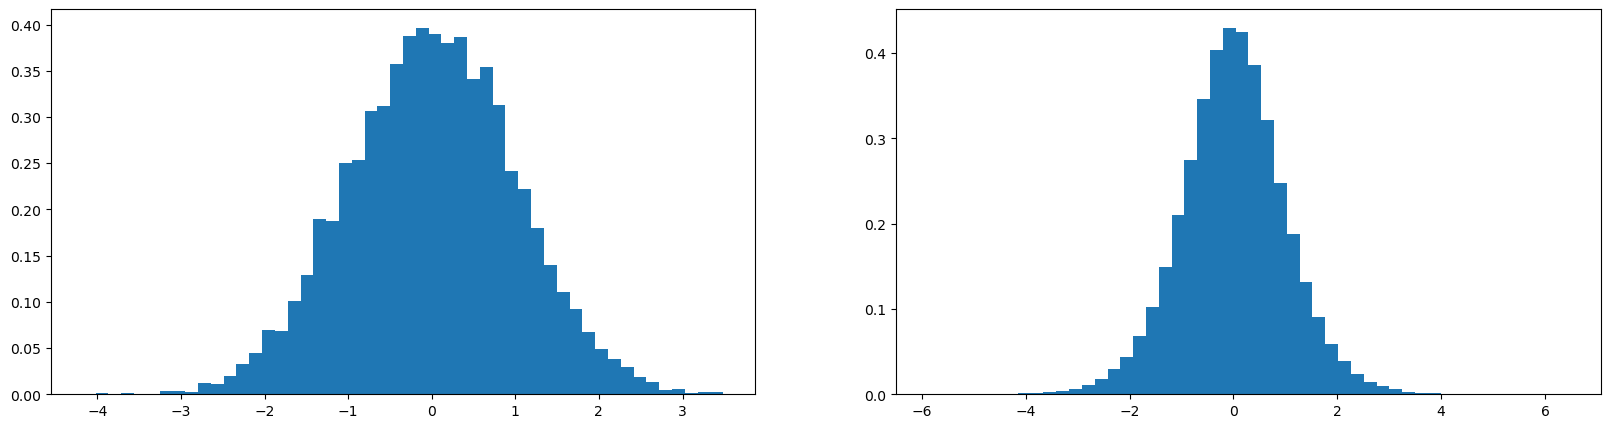

In [17]:
x =torch.randn(1000,10) 
w=torch.randn(10,200) /10**0.5
y=x@w 
print(x.mean(), x.std()) 
print(y.mean(), y.std()) 
plt.figure(figsize=(20,5)) 
plt.subplot(121) 
plt.hist(x.view(-1).tolist(),50,density=True) 
plt.subplot(122) 
plt.hist(y.view(-1).tolist(),50,density=True)